# **_INSTALL DEPENDENCIES_**

In [1]:
import os
import os.path as op
import requests
from urllib.request import urlretrieve
from IPython.display import Markdown, display


def create_folder(folder):
    if not op.exists(folder):
        os.mkdir(folder)
        print(f"Creating:\t\t {folder}")
    else:
        print(f"Already exist:\t\t {folder}")

def download_file(url, filename):
    if not op.exists(filename):
        print(f"Downloading:\t\t {url} --> {filename}")
        urlretrieve(url, filename)
    else:
        print(f"Already downloaded:\t {url} --> {filename}")


url = "https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/README.md"
FILES = "Files"
EX3DATA1_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3data1.mat"
EX3DATA1 = FILES + "/ex3data1.mat"
EX3JORDAN5_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3jordan5.png"
EX3JORDAN5 = FILES + "/ex3jordan5.png"
EX3WEIGHTS_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3weights.mat"
EX3WEIGHTS = FILES + "/ex3weights.mat"

create_folder(FILES)
download_file(EX3DATA1_URL, EX3DATA1)
download_file(EX3WEIGHTS_URL, EX3WEIGHTS)
download_file(EX3JORDAN5_URL, EX3JORDAN5)

Already exist:		 Files
Downloading:		 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3data1.mat --> Files/ex3data1.mat
Downloading:		 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3weights.mat --> Files/ex3weights.mat
Downloading:		 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex3jordan5.png --> Files/ex3jordan5.png


# Step 1: Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import imageio
import scipy.io
from scipy.optimize import fmin_cg

# Step 2: Load Dataset and Display 100 Random Examples

In [4]:
def display_data(data, fig_label="Data", fig_size=5):
    grid_size = int(np.sqrt(np.size(data, 0)))
    if grid_size**2 < np.size(data, 0):
        grid_size += 1

    fig = plt.figure(figsize=(fig_size, fig_size))
    fig.suptitle(fig_label, fontsize=16)

    gs1 = gridspec.GridSpec(grid_size, grid_size)
    gs1.update(wspace=0.05, hspace=0.05)

    img_size = int(np.sqrt(np.size(data[0], 0)))

    for i in range(grid_size * grid_size):
        ax = plt.subplot(gs1[i])
        plt.axis("off")
        if i < np.size(data, 0):
            img = np.reshape(data[i], (img_size, img_size)).T
            ax.imshow(img, cmap="gray")

    plt.show()

Loading and Visualizing Data ...
X shape: (5000, 400) y shape: (5000,)


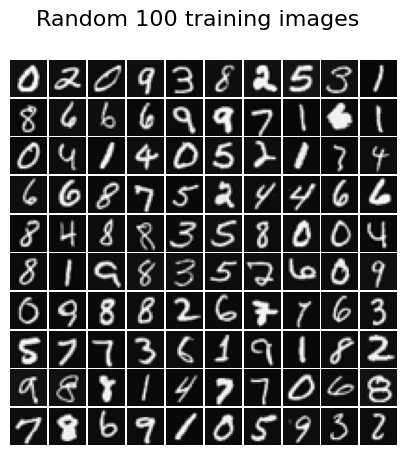

In [5]:
print("Loading and Visualizing Data ...")
data = scipy.io.loadmat(EX3DATA1)
X = data['X']
y = data['y'].T[0]

print("X shape:", X.shape, "y shape:", y.shape)
rand_idx = np.random.permutation(X.shape[0])
sel = X[rand_idx[:100], :]

display_data(sel, "Random 100 training images")

# Step 3: Sanity Check From The Original Exercise

In [6]:
def sigmoid(z):
    #TODO: Implement the sigmoid function
    return 1 / (1 + np.exp(-z))

In [7]:
def lr_cost_function(theta, X, y, lam):
    m = len(y)

    #TODO: Implement the cost function and gradient for logistic regression with regularization
    z = np.dot(X, theta)
    h = sigmoid(z)
    cost = (-1/m) * (y.dot(np.log(h)) + (1-y).dot(np.log(1-h))) + (lam/(2*m)) * np.sum(theta**2)
    grad = (1/m) * X.T.dot(h-y) + (lam/m) * theta

    return cost, grad

In [8]:
theta_t = np.array([-2., -1., 1., 2.])
x_t = np.c_[np.ones((5,1)), np.reshape(np.arange(1, 16), (3,5)).T / 10.0]
y_t = np.array([1, 0, 1, 0, 1])
lambda_t = 3

J, grad = lr_cost_function(theta_t, x_t, y_t, lambda_t)

print("Cost:", J, " (expected ~2.534819)")
print("Grad:", np.round(grad, 6))
print("Expected grad approx: [0.146561 -0.548558 0.724722 1.398003]")

Cost: 3.734819396109744  (expected ~2.534819)
Grad: [-1.053439 -0.548558  0.724722  1.398003]
Expected grad approx: [0.146561 -0.548558 0.724722 1.398003]


# Step 4: Train One-vs-All (may take ~minutes)

In [11]:
def _cost(theta, X, y, lam):
    J, _ = lr_cost_function(theta, X, y, lam)
    return J

def _grad(theta, X, y, lam):
    _, g = lr_cost_function(theta, X, y, lam)
    return g

def one_vs_all(X, y, num_labels, lam):
    m, n = X.shape
    X = np.c_[np.ones(m), X]
    
    all_theta = np.zeros((num_labels, n + 1))

    #TODO: Implement the one-vs-all training for logistic regression
    for i in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_i = np.where(y == (i + 1), 1, 0)
        result = fmin_cg(_cost, initial_theta, fprime=_grad, args=(X, y_i, lam), disp=False)
        all_theta[i] = result

    return all_theta

In [12]:
num_labels = 10
lambda_reg = 0.1

print("Training one-vs-all ... (this may take a little while)")
all_theta = one_vs_all(X, y, num_labels, lambda_reg)
print("Training finished. all_theta shape:", all_theta.shape)

Training one-vs-all ... (this may take a little while)
Training finished. all_theta shape: (10, 401)


# Step 5: Compute Training Accuracy

In [14]:
def predict_one_vs_all(all_theta, X):
    m = X.shape[0]
    X_bias = np.c_[np.ones(m), X]

    #TODO: Implement the prediction for one-vs-all logistic regression
    z = np.dot(X_bias, all_theta.T)
    preds = np.argmax(z, axis=1) + 1 

    return preds

In [15]:
pred = predict_one_vs_all(all_theta, X)
acc = np.mean(pred == y) * 100

print(f"Training set accuracy (one-vs-all): {acc:.2f} %")
print("Predictions matrix shape preview:", np.reshape(pred, (10, 500)).shape)

Training set accuracy (one-vs-all): 96.46 %
Predictions matrix shape preview: (10, 500)


# Step 6: Visualise Learned Thetas As Images

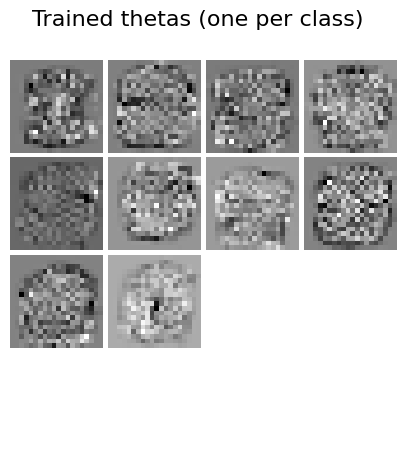

In [16]:
thetas = [all_theta[i, 1:] for i in range(all_theta.shape[0])]
display_data(np.array(thetas), "Trained thetas (one per class)")

# Step 7: Test with Own Image

In [17]:
def load_own_image(name):
    print("Loading image:", name)
    img = imageio.imread(name)

    if img.ndim == 3:
            img = img[:, :, 0]  # take the first channel (R)

    return np.reshape(img.T / 255, (1, 400))

Loading image: Files/ex3jordan5.png
Predicting own image: 5


C:\Users\benja\AppData\Local\Temp\ipykernel_26496\481073950.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(name)


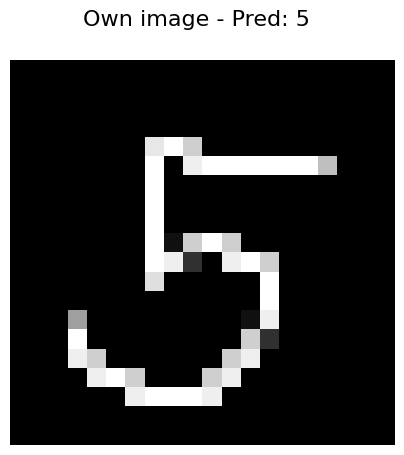

In [18]:
test = load_own_image(EX3JORDAN5)
test_pred = predict_one_vs_all(all_theta, test)

print("Predicting own image:", test_pred[0] % 10)
display_data(test, f"Own image - Pred: {test_pred[0] % 10}")

# Step 8: Load Pre-Trained Weights and Evaluate

In [19]:
def predict_nn(theta1, theta2, X):
    m = X.shape[0]

    # Add bias to input layer
    a1 = np.c_[np.ones(m), X]

    # Layer 2
    z2 = a1 @ theta1.T
    a2 = np.c_[np.ones(m), sigmoid(z2)]

    # Output layer
    z3 = a2 @ theta2.T
    a3 = sigmoid(z3)

    # Prediction = index of max activation + 1
    return np.argmax(a3, axis=1) + 1

Loading Saved Neural Network Parameters ...
Theta1 shape: (25, 401) Theta2 shape: (10, 26)
Training set accuracy (pre-trained NN): 97.52 %


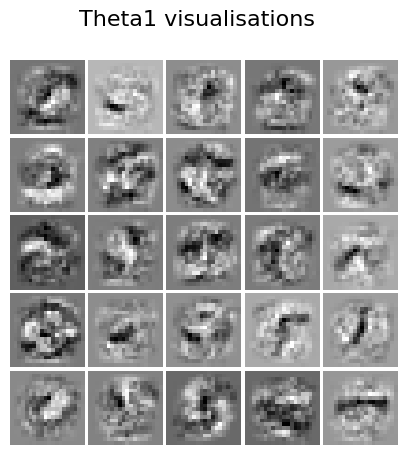

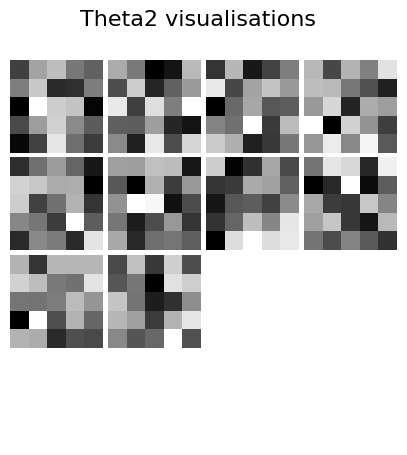

In [20]:
print("Loading Saved Neural Network Parameters ...")
weights = scipy.io.loadmat(EX3WEIGHTS)

theta1, theta2 = weights['Theta1'], weights['Theta2']
print("Theta1 shape:", theta1.shape, "Theta2 shape:", theta2.shape)

pred_nn = predict_nn(theta1, theta2, X)
acc_nn = np.mean(pred_nn == y) * 100
print(f"Training set accuracy (pre-trained NN): {acc_nn:.2f} %")

# display some theta visualizations (theta1 and theta2)
t1_viz = [theta1[i,1:] for i in range(theta1.shape[0])]
display_data(np.array(t1_viz), "Theta1 visualisations")

t2_viz = [theta2[i,1:] for i in range(theta2.shape[0])]
display_data(np.array(t2_viz), "Theta2 visualisations")

# Step 9: Test Own Image with NN

Loading image: Files/ex3jordan5.png
NN predicts for own image (mod 10): 5


C:\Users\benja\AppData\Local\Temp\ipykernel_26496\481073950.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(name)


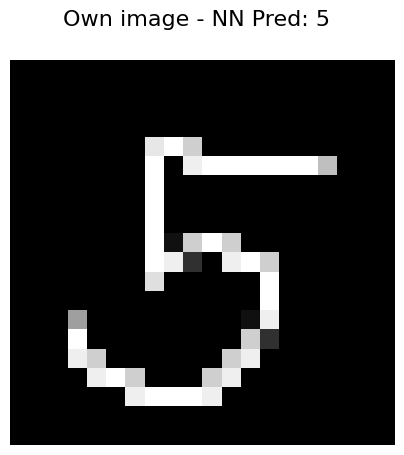

In [21]:
test = load_own_image(EX3JORDAN5)
pred_test_nn = predict_nn(theta1, theta2, test)
print("NN predicts for own image (mod 10):", pred_test_nn[0] % 10)
display_data(test, f"Own image - NN Pred: {pred_test_nn[0] % 10}")

# Step 10: Examples

Index 4816 - Predicted: 9 - Label: 9


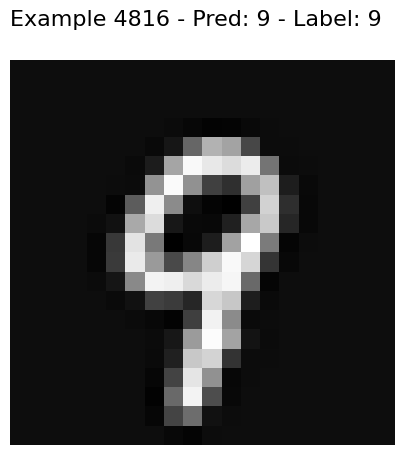

Index 1316 - Predicted: 2 - Label: 2


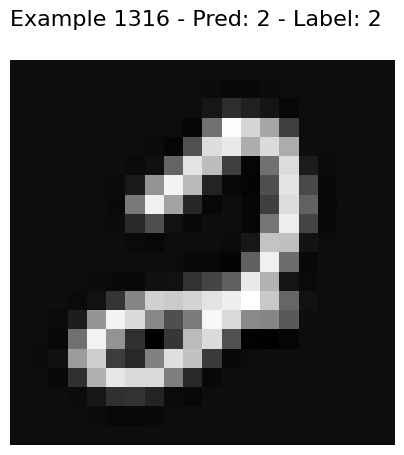

Index 98 - Predicted: 0 - Label: 0


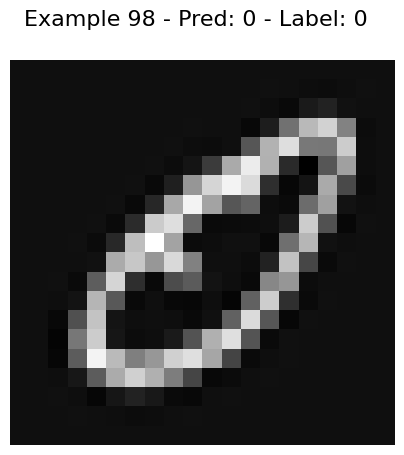

In [22]:
rp = np.random.permutation(X.shape[0])

for i in rp[:3]:
    ex = X[i].reshape(1, -1)
    p = predict_nn(theta1, theta2, ex)[0] % 10

    print(f"Index {i} - Predicted: {p} - Label: {y[i] % 10}")
    display_data(ex, f"Example {i} - Pred: {p} - Label: {y[i] % 10}")